In [1]:
import copy
import functools
import glob
import pickle
import scipy
import sklearn
import warnings

warnings.filterwarnings('ignore')

import itertools
import graphviz as gr
import matplotlib.dates as mdates
import numpy as np
import os
import pandas as pd
import statsmodels.formula.api as smf


from matplotlib import style
from matplotlib import pyplot as plt
from pprint import pprint
from scipy import stats, special
from sklearn import mixture
from sklearn import datasets
from tqdm import tqdm

%matplotlib inline

style.use("fivethirtyeight")
pd.set_option("display.max_columns", 6)

np.random.seed(0)

In [2]:
#!pip freeze > ../requirements.txt
#!pip install -r ../requirements.txt --user

# File Locations

In [3]:
DATA_FOLDER = "../data"
COLORADO_BACKTEST_PATH = os.path.join(DATA_FOLDER,"colorado_backtest.csv")
COLORADO_OUTBREAKS_PATH =  os.path.join(DATA_FOLDER,"colorado_outbreaks.csv")
OUTPUT_FOLDER = "../output"

### Load the Outbreak Data

In [4]:
colorado_outbreaks_df = pd.read_csv(COLORADO_OUTBREAKS_PATH, parse_dates=True) 
colorado_outbreaks_df = colorado_outbreaks_df.drop(columns=["Setting name","At Risk"])
# Transform date columns
colorado_outbreaks_df["Date Resolved"] = pd.to_datetime(colorado_outbreaks_df["Date Resolved"])
colorado_outbreaks_df["Date Reported"] = pd.to_datetime(colorado_outbreaks_df["Date Reported"])

# Groupby fips and sort by date
colorado_outbreaks_df = colorado_outbreaks_df.groupby("fips").apply(lambda x: x.sort_values(by="Date Reported")).drop("fips", axis=1)
colorado_outbreaks_df = colorado_outbreaks_df.reset_index().drop("level_1",axis=1)



colorado_outbreaks_df

,fips,Date Resolved,County,Date Reported,Total cases,Total deaths
0,8001,2020-05-19,Adams,2020-03-23,39,8
1,8001,2020-05-07,Adams,2020-03-24,2,0
2,8001,2020-07-02,Adams,2020-04-03,52,10
3,8001,2020-07-16,Adams,2020-04-03,98,26
4,8001,2020-06-09,Adams,2020-04-06,38,3
...,...,...,...,...,...,...
4493,8125,2021-04-02,Yuma,2021-03-08,3,0
4494,8125,2021-06-14,Yuma,2021-04-19,6,0
4495,8125,2021-05-25,Yuma,2021-05-11,10,0
4496,8125,2021-06-10,Yuma,2021-05-21,2,0


In [5]:
colorado_outbreaks_df["fips"].unique().shape

(54,)

### Generate Contiguous Dates of Outbreaks and Non-Outbreak periods for each county

In [6]:
date_start = colorado_outbreaks_df[["Date Reported","Date Resolved"]].min().min()
date_end = colorado_outbreaks_df[["Date Reported","Date Resolved"]].max().max()
print("Date Start {} till Date End {}".format(date_start,date_end))
# Generate Range of Dates
dates_array = pd.date_range(date_start,date_end,freq='d')
# Generate Array of fips from master fips file, since CDPHE does not investigate ALL counties
county_fips_master_df = pd.read_csv(os.path.join(OUTPUT_FOLDER, "county_fips_master.csv"))
county_fips_master_df = county_fips_master_df[county_fips_master_df["state_abbr"]=="CO"]
fips_array = county_fips_master_df["fips"]

Date Start 2020-03-17 00:00:00 till Date End 2021-09-01 00:00:00


In [12]:
OUTBREAK_MATRIX_PATH = os.path.join(DATA_FOLDER,"colorado_outbreak_matrix.csv")
if not os.path.isfile(OUTBREAK_MATRIX_PATH) or True: 


    # Generate Outbreak Matrix of Zeros
    outbreak_matrix = pd.DataFrame(0, index = dates_array, columns=fips_array.astype(str))
    # For each entry in colorado_outbreaks_df, set the daterange x fips to 1
    for i in range(colorado_outbreaks_df.shape[0]):
        entry = colorado_outbreaks_df.iloc[i]
        fips = str(entry["fips"])
        drange = pd.date_range(entry["Date Reported"],entry["Date Resolved"],freq='d')
        outbreak_matrix.loc[drange, fips] = 1
        #break
    outbreak_matrix.to_csv(OUTBREAK_MATRIX_PATH,index=True)
else:
    outbreak_matrix = pd.read_csv(OUTBREAK_MATRIX_PATH,parse_dates=True, index_col=0)
outbreak_matrix

fips,8001,8003,8005,...,8121,8123,8125
2020-03-17,0,0,0,...,0,1,0
2020-03-18,0,0,1,...,0,1,0
2020-03-19,0,0,1,...,0,1,0
2020-03-20,0,0,1,...,0,1,0
2020-03-21,0,0,1,...,0,1,0
...,...,...,...,...,...,...,...
2021-08-28,0,0,1,...,0,0,0
2021-08-29,0,0,1,...,0,0,0
2021-08-30,0,0,1,...,0,0,0
2021-08-31,0,0,1,...,0,0,0


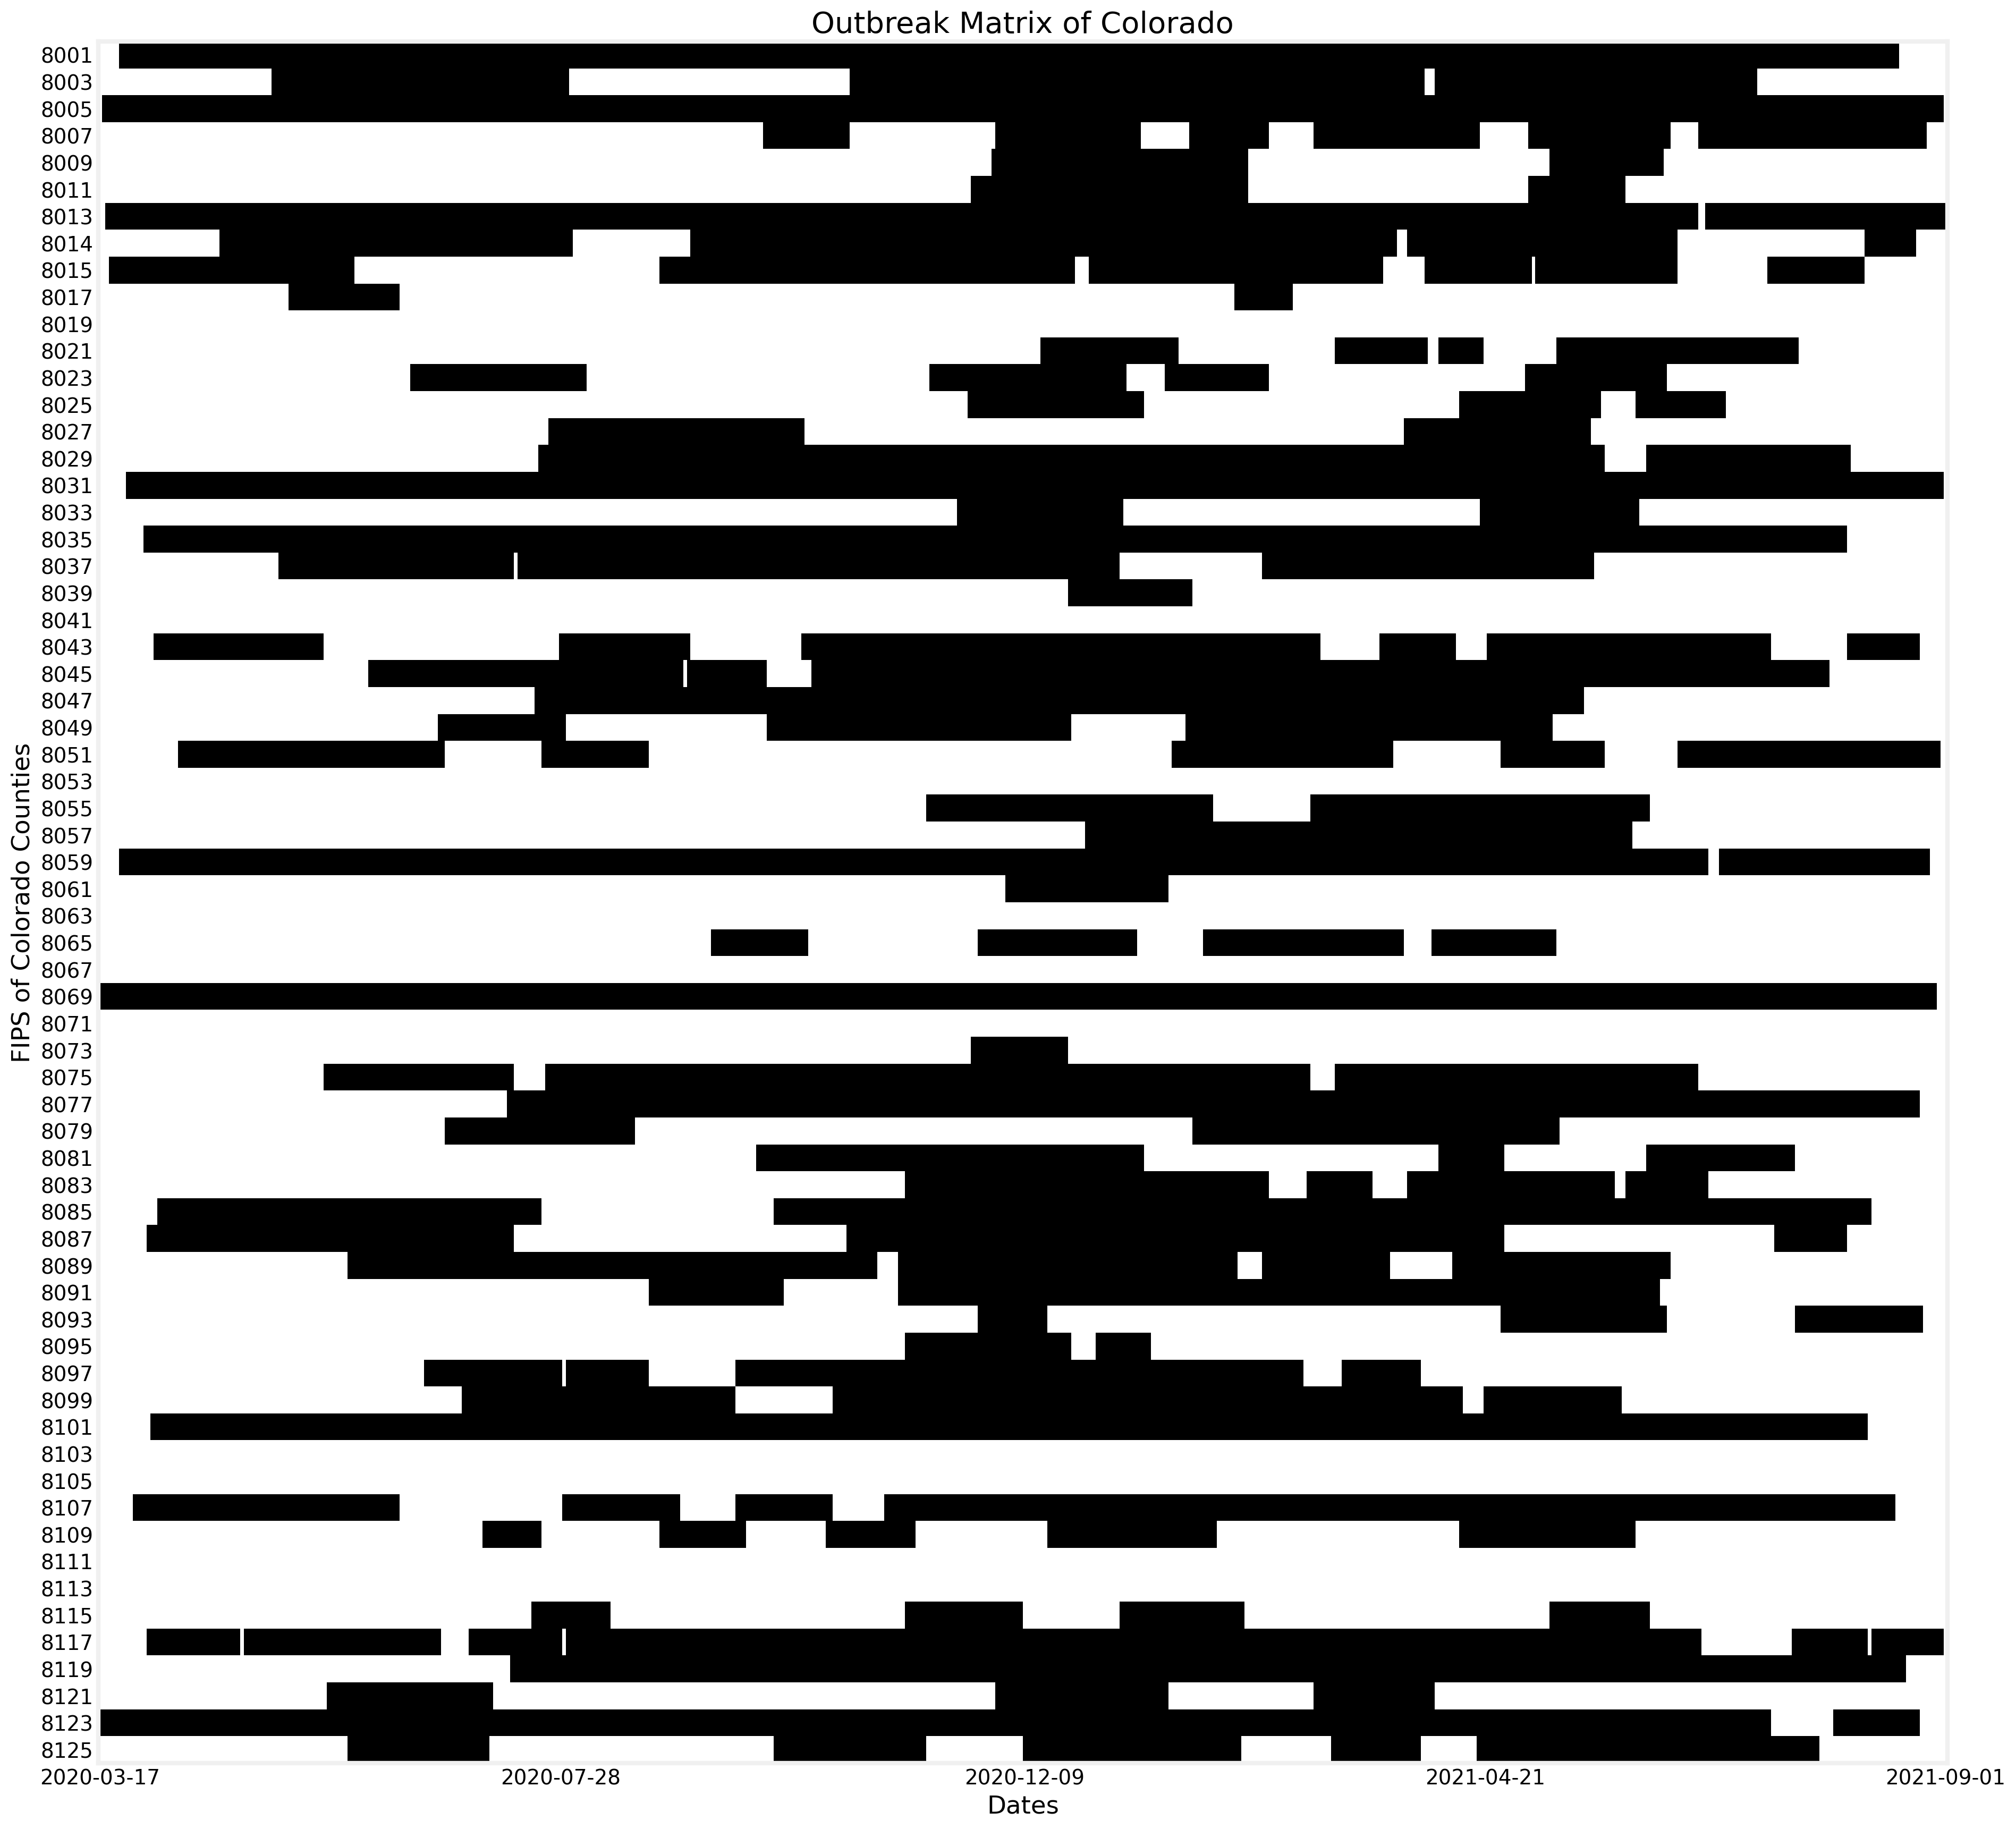

In [13]:
fig, ax =plt.subplots(1,1,figsize=(20,20), dpi= 200, facecolor='w', edgecolor='k')
#plt.rcParams['figure.dpi'] = 200

#plt.xlabel(outbreak_matrix.index)
x_lims = [0, 534//4, 534//2, 3*534//4 , 533]
#x_labels = mdates.date2num(outbreak_matrix.index)
x_labels = outbreak_matrix.index.astype(str)
x_labels = x_labels[x_lims]

y_lims = outbreak_matrix.columns

y_label_list = np.array(outbreak_matrix.columns.astype(np.int64))

img = ax.imshow(outbreak_matrix.T, cmap='Greys', aspect="auto")

ax.set_xticks(x_lims)
ax.set_xticklabels(x_labels)
ax.set_yticks(range(len(y_label_list)))
ax.set_yticklabels(y_label_list)



ax.set_title("Outbreak Matrix of Colorado")
ax.set_ylabel("FIPS of Colorado Counties")
ax.set_xlabel("Dates")
#plt.yticks(ticks=y_label_list ,labels=y_label_list)
#plt.xticks(ticks=x_lims ,labels=x_lims)

#plt.imshow(outbreak_matrix.T, cmap='Greys', aspect="auto")
plt.grid(None)
plt.savefig("../figures/Outbreak_Matrix.png")
plt.show()

### Change points from 0 -> 1 to indicate no outbreak to outbreak

In [14]:
changepoint_matrix = outbreak_matrix.diff() 
changepoint_matrix[changepoint_matrix["8003"]==1]["8003"]

2020-05-06    1.0
2020-10-20    1.0
2021-04-07    1.0
Name: 8003, dtype: float64

### Get the actual cases on the day itself `x` from 7 days later `y`

In [15]:
colorado_backtest_df = pd.read_csv(COLORADO_BACKTEST_PATH, parse_dates=True) 
colorado_backtest_df["date.y"] = pd.to_datetime(colorado_backtest_df["date.y"])
colorado_backtest_df["date.x"] = colorado_backtest_df["date.y"] +pd.DateOffset(days=-6)
colorado_backtest_df["days_from_start.x"] = colorado_backtest_df["days_from_start.y"] - 7
colorado_backtest_df = colorado_backtest_df[colorado_backtest_df["date.y"] <= date_end]

colorado_backtest_df = colorado_backtest_df.dropna(subset=["log_rolled_cases.y"])
# Sort by date within each group
colorado_backtest_df = colorado_backtest_df.groupby("fips").apply(lambda x: x.sort_values(by="date.y"))
#colorado_backtest_df = colorado_backtest_df.reset_index().drop("level_1",axis=1)
# Shift dates cases back by 7
colorado_backtest_df["log_rolled_cases.x"] = colorado_backtest_df.groupby("fips")["log_rolled_cases.y"].shift(7)
colorado_backtest_df = colorado_backtest_df.dropna(subset=["log_rolled_cases.x"])
# Find out what's the "ground true" growth rate
colorado_backtest_df["r.gt"] = (colorado_backtest_df["log_rolled_cases.y"] - colorado_backtest_df["log_rolled_cases.x"])/7
colorado_backtest_df

,fips,county,r.lm,...,days_from_start.x,log_rolled_cases.x,r.gt
7,10001,Kent,0.222262,...,77,4.394449,0.162464
8,10001,Kent,0.248567,...,78,4.643016,0.137391
9,10001,Kent,0.207897,...,79,4.850914,0.116925
10,10001,Kent,0.175783,...,80,5.026696,0.101279
11,10001,Kent,0.158293,...,81,5.184989,0.087915
...,...,...,...,...,...,...,...
1497892,99999,New York City,0.023726,...,578,10.542492,0.014954
1497893,99999,New York City,0.021841,...,579,10.564333,0.011836
1497894,99999,New York City,0.018435,...,580,10.582768,0.009814
1497895,99999,New York City,0.017927,...,581,10.600694,0.008368


### Attach entries where we do have outbreaks

In [11]:
outbreak_backtest_df = colorado_backtest_df.copy()
outbreak_backtest_df["outbreak.gt"] = 0
for fips in fips_array:
    fipsmask = (outbreak_backtest_df["fips"] == fips)
    drange = outbreak_backtest_df.loc[fipsmask,"date.x"]
    outbreak_backtest_df.loc[fipsmask,"outbreak.gt"] = [[i] for i in outbreak_matrix.loc[drange,str(fips)]]


KeyError: '8019'

In [ ]:
outbreak_backtest_df

In [ ]:
outbreak_backtest_df.to_csv(os.path.join(DATA_FOLDER,"outbreak_backtest_df.csv"),index=False)

In [ ]:
break

### Possible `r_threshold` ranges

In [ ]:
rmax = colorado_backtest_df[["r.lm","r.grf","r.gt"]].max().max()
rmin = colorado_backtest_df[["r.lm","r.grf","r.gt"]].min().min()

r_threshold_range = np.linspace(rmin, rmax, 120)
lookahead_range = [0,1,7,14,21]
classifier_list = ["lm","grf","gt"]

params = {}
params["r_thresholds"] = r_threshold_range
params["lookaheads"] = lookahead_range
params["classifiers"] = classifier_list

### Find Optimal F1 `r_threshold` overall

In [ ]:
def classification(outbreak_backtest_df, lookahead, r_threshold, classifier):
    """
    Takes in the outbreak_backtest_df data
    Given a specific lookahead and threshold
    such that prediction = (estimated_r >= threshold)
    
    classifier = ["lm", "grf", "gt"]
    
    Return TP, FN, TN, FP
    """
    test_df =  outbreak_backtest_df.copy()
    test_df["prediction." + classifier] = 0
    # Generate Predictions
    r_predicted = (test_df["r." + classifier] >= r_threshold).astype(int)
    test_df["prediction." + classifier] = r_predicted
    test_df["lookahead_range"] = 0
    # Now compute the TP, FP, TN, FN based off changepoints
    # With a lookahead of 7 days, if a county transitions into outbreak at '2020-05-28'
    # Then any alarm raised from 2020-05-21 to 2020-05-28 counts as TP
    # No alarm raised counts as FN
    # Alarms raised on days outside such changepoint ranges that are not undergoing outbreak are FP
    # No alarms raised on days outside such changepoint ranges are TN
    TP, FP, TN, FN = 0,0,0,0
    for fips in fips_array:
        fipsmask = (test_df["fips"]==fips)
        sample_backtest_df = test_df[fipsmask]
        county_changepoints = changepoint_matrix[changepoint_matrix[str(fips)]==1][str(fips)].index
        # Find dates where they are indeed part of the lookahead
        for changepoint in county_changepoints:
            dranges = pd.date_range(changepoint  + pd.DateOffset(days=-lookahead + 1), changepoint ,freq="d")
            drangemask = (test_df["date.x"].isin(dranges))
            test_df.loc[fipsmask & drangemask,"lookahead_range"] = 1
            # Compute whether it is a TP or FN
            if np.any(test_df.loc[fipsmask & drangemask,"prediction." + classifier]):
                TP += 1
            else:
                FN += 1
    # Compute whether it is a FP or TN
    # Only look through date ranges where it is a NOR(lookahead_range,outbreak.gt)
    no_outbreak_mask = ~(test_df["lookahead_range"].astype(bool) |  test_df["outbreak.gt"].astype(bool))
    FP = test_df.loc[no_outbreak_mask,"prediction." + classifier].sum()
    TN = len(test_df.loc[no_outbreak_mask,"prediction." + classifier]) - FP
    
    result_dict = { "TP":TP, "FP":FP, "TN":TN, "FN":FN, "lookahead":lookahead, "r_threshold": r_threshold, "classifier":classifier}
    
    result_dict["prediction." + classifier] = test_df["prediction." + classifier]
    result_dict["outbreak.gt"] = test_df["outbreak.gt"]
    
    TPR = TP / (TP + FN)
    TNR = TN /  (TN + FP)
    FNR = 1 - TPR
    FPR = 1 - TNR
    
    P = FN + TP
    N = FP + TN
    ACC = (TP + TN)/(P + N)
    F1 = 2*TP/(2*TP + FP + FN)
    
    result_dict["TPR"] = TPR
    result_dict["TNR"] = TNR
    result_dict["FNR"] = FNR
    result_dict["FPR"] = FPR
    
    result_dict["P"] = P
    result_dict["N"] = N
    result_dict["ACC"] = ACC
    result_dict["F1"] = F1
    
    return result_dict

In [ ]:
lookahead = lookahead_range[0]
r_threshold = r_threshold_range[10]
classifier = "grf"
classification(outbreak_backtest_df, lookahead, r_threshold, classifier)

In [ ]:


big_dict = {}

for key in tqdm(list(itertools.product(classifier_list,r_threshold_range, lookahead_range))):
    classifier, r_threshold, lookahead = key
    big_dict[(classifier, r_threshold, lookahead)]=classification(outbreak_backtest_df, lookahead, r_threshold, classifier)

In [ ]:
OUTPUT_FOLDER = "../output"
BIG_DICT_PATH = os.path.join(OUTPUT_FOLDER,"big_dict_colorado.p")
with open(BIG_DICT_PATH,"wb+") as handle:
    pickle.dump(big_dict, handle)

In [ ]:

PARAMS_PATH = os.path.join(OUTPUT_FOLDER,"params_colorado.p")
with open(PARAMS_PATH,"wb+") as handle:
    pickle.dump(params, handle)